This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      151
Number of nonzeros in inequality constraint Jacobian.:      402
Number of nonzeros in Lagrangian Hessian.............:       50

Total number of variables............................:      101
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       51
Total number of inequality constraints...............:      302
        inequality constraints with only lower bounds:      151
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:      151

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -2.0000000e-01 7.20e-02 2.39e-03  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

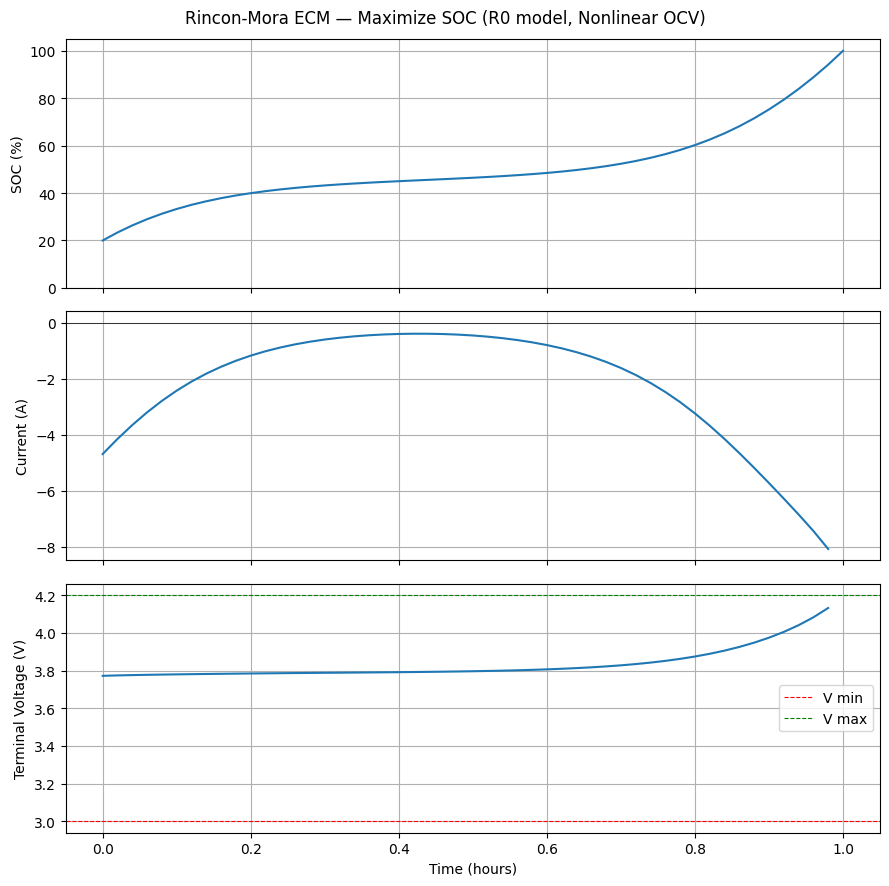

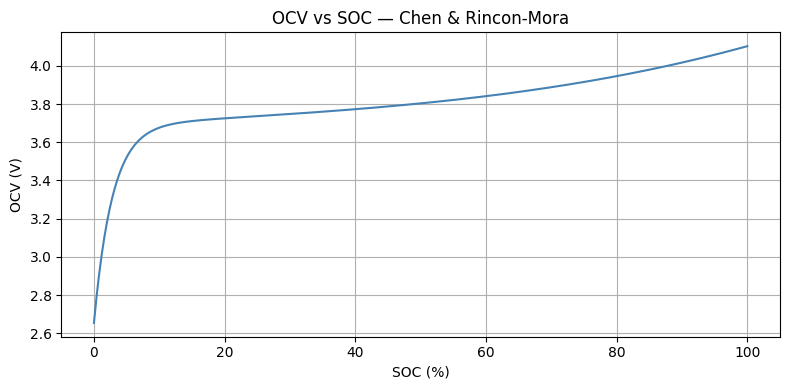

Initial SOC : 20.0%
Final SOC   : 100.0%
SOC gained  : 80.0%


In [ ]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt

# Static Parameters
N = 50
T = 3600.0
dt = T / N
I_max = 10.0
Q_max = 10000.0
R0 = 0.01

opti = ca.Opti()
X = opti.variable(1, N+1)
U = opti.variable(1, N)

soc = X[0, :]
I = U[0, :]  # fix: was U[0:]

# Cost function: maximize final SOC
opti.minimize(-soc[N])

# Dynamics
for k in range(N):
    opti.subject_to(soc[k+1] == soc[k] + dt * (-I[k] / Q_max))

# OCV function
def V_OCV(SOC):
    return (
        -1.031 * ca.exp(-35.5 * SOC)
        + 3.685
        + 0.2156 * SOC
        - 0.1178 * SOC**2
        + 0.3201 * SOC**3
    )

v_bat = V_OCV(soc[:-1]) - I * R0  

# Boundary constraints
opti.subject_to(soc >= 0.0)
opti.subject_to(soc <= 1.0)
opti.subject_to(I   >= -I_max)
opti.subject_to(I   <=  I_max)
opti.subject_to(v_bat >= 3.0)
opti.subject_to(v_bat <= 4.2)
opti.subject_to(soc[0] == 0.2)

opti.set_initial(soc, 0.2 * np.ones(N+1))
opti.set_initial(I, -I_max * np.ones(N))

# Solver
opti.solver('ipopt')
val = opti.solve()

# Extract values
SOC_opt = val.value(soc)
I_opt   = val.value(I)

# Use numpy exp for post-solve evaluation
def V_OCV_np(SOC):
    return (
        -1.031 * np.exp(-35.5 * SOC)
        + 3.685
        + 0.2156 * SOC
        - 0.1178 * SOC**2
        + 0.3201 * SOC**3
    )

V_OCV_opt = V_OCV_np(SOC_opt)
V_bat_opt = V_OCV_opt[:-1] - I_opt * R0
t = np.linspace(0, T, N+1)

# ── Plot 1: Optimization results ─────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(t / 3600, SOC_opt * 100)
axes[0].set_ylabel('SOC (%)')
axes[0].set_ylim(0, 105)
axes[0].grid(True)

axes[1].plot(t[:-1] / 3600, I_opt)
axes[1].set_ylabel('Current (A)')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].grid(True)

axes[2].plot(t[:-1] / 3600, V_bat_opt)
axes[2].set_ylabel('Terminal Voltage (V)')
axes[2].set_xlabel('Time (hours)')
axes[2].axhline(3.0, color='r', linestyle='--', linewidth=0.8, label='V min')
axes[2].axhline(4.2, color='g', linestyle='--', linewidth=0.8, label='V max')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Rincon-Mora ECM — Maximize SOC (R0 model, Nonlinear OCV)')
plt.tight_layout()
plt.show()

# ── Plot 2: OCV vs SOC curve ─────────────────────────────────────
SOC_range = np.linspace(0, 1, 500)
OCV_range = V_OCV_np(SOC_range)

plt.figure(figsize=(8, 4))
plt.plot(SOC_range * 100, OCV_range, color='steelblue')
plt.xlabel('SOC (%)')
plt.ylabel('OCV (V)')
plt.title('OCV vs SOC — Chen & Rincon-Mora')
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Summary ──────────────────────────────────────────────────────
print(f"Initial SOC : {SOC_opt[0]*100:.1f}%")
print(f"Final SOC   : {SOC_opt[-1]*100:.1f}%")
print(f"SOC gained  : {(SOC_opt[-1] - SOC_opt[0])*100:.1f}%")

Max simulated temperature: 34.10405530319239
Analytical steady-state  : 81.25


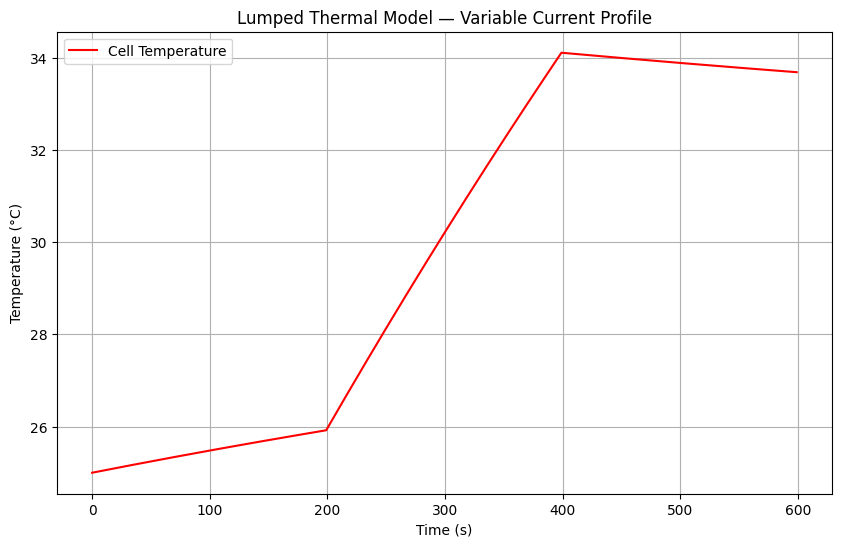

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ── Battery & Thermal Parameters ──────────────────────────────────────────────
I = 10          # A      — initial discharge current (overridden in loop)
A = 0.004       # m²     — surface area of the battery cell
h = 10          # W/m²K  — convective heat transfer coefficient
c = 1000        # J/kgK  — specific heat capacity
m = 0.05        # kg     — cell mass
R = 0.01        # Ω      — internal resistance (heat source: I²R)
T_amb = 25      # °C     — ambient temperature
T_initial = 25  # °C     — initial cell temperature

# ── Simulation Time Setup ─────────────────────────────────────────────────────
dt = 1                    # s  — time step (integer, so range() works cleanly)
timestep = 600            # total number of time steps
Time = np.arange(0, 600)  # time array in seconds

# ── Pre-allocate Temperature Array and Set Initial Condition ──────────────────
T = np.zeros(timestep)
T[0] = T_initial

# ── Euler Integration with Variable Current Profile ───────────────────────────
# Current switches in three phases to simulate a charge/discharge cycle:
#   t = 0–199s  : low current  (I = 5A)
#   t = 200–399s: high current (I = 15A)  ← drives cell toward peak temperature
#   t = 400–599s: low current  (I = 5A)   ← cell cools toward new steady state
for i in range(1, timestep, dt):
    if i < 200:
        I = 5
    elif i < 400:
        I = 15
    else:
        I = 5

    # Lumped thermal ODE (single-mass):
    # dT/dt = (I²R — convective heat loss) / (m*c)
    DT = ((I**2) * R - h * A * (T[i-1] - T_amb)) / (m * c)

    # Euler forward step: T(i) = T(i-1) + dt * dT
    T[i] = T[i-1] + dt * DT

# ── Steady-State Temperature Check ────────────────────────────────────────────
# At steady state dT/dt = 0, so: I²R = h*A*(T_steady - T_amb)
# Rearranging: T_steady = T_amb + I²R / (h*A)
T_steady = T_amb + (15**2) * R / (h * A)
print('Max simulated temperature:', T.max())
print('Analytical steady-state  :', T_steady)

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.plot(Time, T, color='red', label='Cell Temperature')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Lumped Thermal Model — Variable Current Profile')
plt.legend()
plt.grid(True)
plt.show()

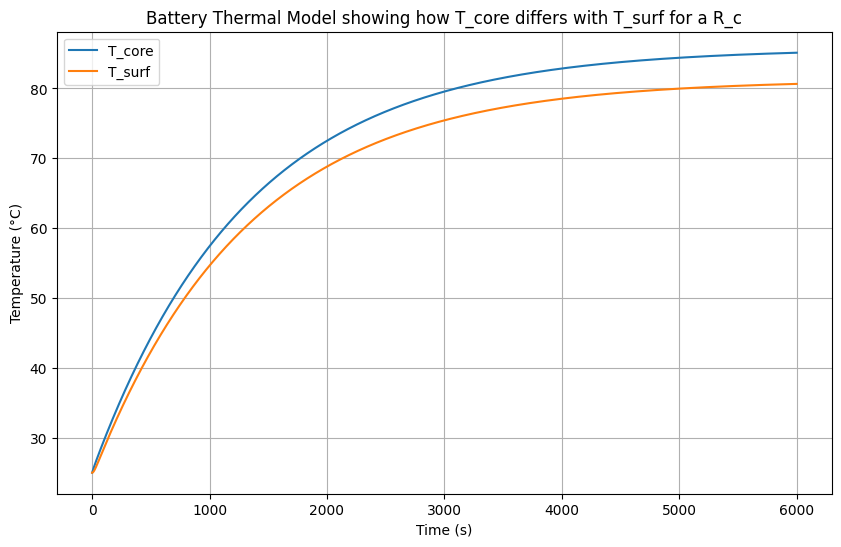

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# ── Battery & Thermal Parameters ──────────────────────────────────────────────
I = 15          # A      — discharge current
A = 0.004       # m²     — surface area of the battery cell
h = 10          # W/m²K  — convective heat transfer coefficient
c = 1000        # J/kgK  — specific heat capacity (shared for core and surface)
m = 0.05        # kg     — total cell mass
R = 0.01        # Ω      — internal resistance (heat source: I²R)
T_amb = 25      # °C     — ambient temperature
T_initial = 25  # °C     — initial temperature of core and surface

# ── Simulation Time Setup ─────────────────────────────────────────────────────
dt = 0.1                              # s  — Euler integration time step
timestep = 60000                      # number of time steps
Time = np.arange(0, timestep*dt, dt)  # time array in seconds

# ── Two-Mass Thermal Model Parameters ─────────────────────────────────────────
# Heat flow path: core (I²R source) → surface (via R_c) → ambient (via convection)
R_c = 2      # K/W — fixed core-to-surface thermal resistance
m_c = 0.04   # kg  — core mass
m_s = 0.01   # kg  — surface mass

# ── Pre-allocate Temperature Arrays and Set Initial Conditions ─────────────────
T_core = np.zeros(timestep)
T_core[0] = T_initial  # core starts at ambient temperature

T_surf = np.zeros(timestep)
T_surf[0] = T_initial  # surface starts at ambient temperature

# ── Euler Integration ──────────────────────────────────────────────────────────
for i in range(1, timestep):
    # Rate of change of core temperature:
    # Heat generated (I²R) minus heat conducted out to surface through R_c
    dT_core = ((I**2) * R - (T_core[i-1] - T_surf[i-1]) / R_c) / (m_c * c)

    # Rate of change of surface temperature:
    # Heat conducted in from core minus convective heat loss to ambient
    dT_surf = ((T_core[i-1] - T_surf[i-1]) / R_c - h * A * (T_surf[i-1] - T_amb)) / (m_s * c)

    # Euler forward step: T(i) = T(i-1) + dt * dT
    T_core[i] = T_core[i-1] + dt * dT_core
    T_surf[i] = T_surf[i-1] + dt * dT_surf

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.plot(Time, T_core, label='T_core')
plt.plot(Time, T_surf, label='T_surf')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Battery Thermal Model showing how T_core differs with T_surf for a R_c')
plt.legend()
plt.grid(True)
plt.show()

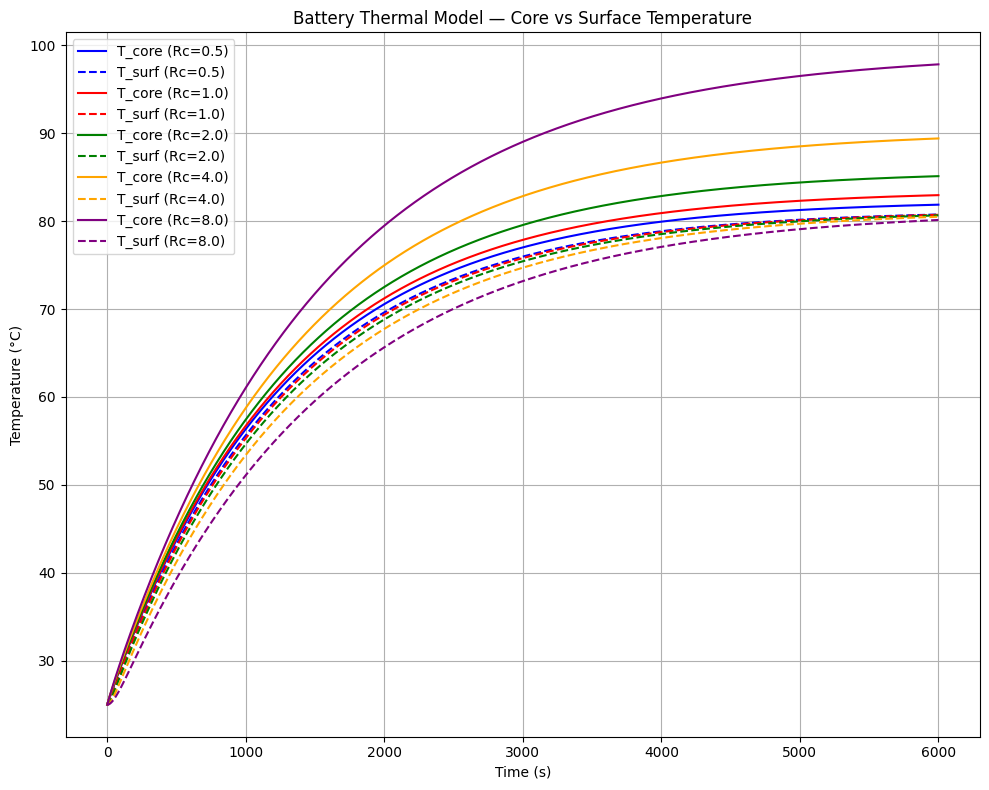

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ── Battery & Thermal Parameters ──────────────────────────────────────────────
I = 15          # A      — discharge current
A = 0.004       # m²     — surface area of the battery cell
h = 10          # W/m²K  — convective heat transfer coefficient
c = 1000        # J/kgK  — specific heat capacity (shared for core and surface)
m = 0.05        # kg     — total cell mass
R = 0.01        # Ω      — internal resistance (heat source: I²R)
T_amb = 25      # °C     — ambient temperature
T_initial = 25  # °C     — initial temperature of core and surface

# ── Simulation Time Setup ─────────────────────────────────────────────────────
dt = 0.1                              # s  — Euler integration time step
timestep = 60000                      # number of time steps
Time = np.arange(0, timestep*dt, dt)  # time array in seconds

# ── Two-Mass Thermal Model Parameters ─────────────────────────────────────────
# The cell is split into a core mass and a surface mass connected by R_c.
# Heat flows: core (I²R source) → surface (via R_c) → ambient (via convection)
R_c = [0.5, 1.0, 2.0, 4.0, 8.0]  # K/W — core-to-surface thermal resistance values to sweep
m_c = 0.04   # kg — core mass
m_s = 0.01   # kg — surface mass

# ── Pre-allocate Temperature Arrays ───────────────────────────────────────────
T_core = np.zeros(timestep)  # core temperature at each time step
T_surf = np.zeros(timestep)  # surface temperature at each time step

# ── Plot Setup ────────────────────────────────────────────────────────────────
colors = ['blue', 'red', 'green', 'orange', 'purple']  # one color per R_c value

plt.figure(figsize=(10, 8))
plt.grid(True)

# ── Euler Integration Loop — sweep over each R_c value ────────────────────────
for b, color in zip(R_c, colors):

    # Set initial conditions for this R_c run
    T_core[0] = T_surf[0] = T_initial

    for i in range(1, timestep):
        # Rate of change of core temperature:
        # Heat generated (I²R) minus heat lost to surface through thermal resistance b
        dT_core = ((I**2) * R - (T_core[i-1] - T_surf[i-1]) / b) / (m_c * c)

        # Rate of change of surface temperature:
        # Heat gained from core minus convective heat loss to ambient
        dT_surf = ((T_core[i-1] - T_surf[i-1]) / b - h * A * (T_surf[i-1] - T_amb)) / (m_s * c)

        # Euler forward integration: T(i) = T(i-1) + dt * dT
        T_core[i] = T_core[i-1] + dt * dT_core
        T_surf[i] = T_surf[i-1] + dt * dT_surf

    # Plot core (solid) and surface (dashed) in the same color for easy pairing
    plt.plot(Time, T_core, label=f'T_core (Rc={b})', color=color)
    plt.plot(Time, T_surf, label=f'T_surf (Rc={b})', linestyle='--', color=color)

# ── Plot Formatting ───────────────────────────────────────────────────────────
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Battery Thermal Model — Core vs Surface Temperature')
plt.legend()
plt.tight_layout()
plt.show()